In [1]:
import pandas as pd
import numpy as np

### LOADING CSV DATASET & ASSIGNING CORRECT DATA TYPES

In [2]:
data = pd.read_csv('breast_cancer_data.csv')
data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
missing_values = data.isnull().sum()
print('Missing Values:')
missing_values

Missing Values:


id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave_points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave_points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave_points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

In [4]:
data.dtypes

id                           int64
diagnosis                   object
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave_points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave_points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_worst          float64
concavity_worst     

In [5]:
duplicates = data.duplicated()
data[duplicates]

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst


### FINDING UNIQUE VALUES & IDENTIFY COLUMNS WITH UNNECCESSARY CATEGORIES

In [6]:
data.nunique()

id                         569
diagnosis                    2
radius_mean                456
texture_mean               479
perimeter_mean             522
area_mean                  539
smoothness_mean            474
compactness_mean           537
concavity_mean             537
concave_points_mean        542
symmetry_mean              432
fractal_dimension_mean     499
radius_se                  540
texture_se                 519
perimeter_se               533
area_se                    528
smoothness_se              547
compactness_se             541
concavity_se               533
concave_points_se          507
symmetry_se                498
fractal_dimension_se       545
radius_worst               457
texture_worst              511
perimeter_worst            514
area_worst                 544
smoothness_worst           411
compactness_worst          529
concavity_worst            539
concave_points_worst       492
symmetry_worst             500
fractal_dimension_worst    535
dtype: i

### EXPLORATORY DATA ANALYSIS

In [7]:
data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### Frequency & Percentage Analysis

In [8]:
freq = data['diagnosis'].value_counts()
print('Frequency of each diagnosis class:\n', freq)

Frequency of each diagnosis class:
 diagnosis
B    357
M    212
Name: count, dtype: int64


In [9]:
percent = data['diagnosis'].value_counts(normalize = True) * 100
print('\nPercentage of each diagnosis class:\n', percent.round(2))


Percentage of each diagnosis class:
 diagnosis
B    62.74
M    37.26
Name: proportion, dtype: float64


In [10]:
# combine frequency & percentage analysis into a summary table
summary = pd.DataFrame({'Frequency': freq, 'Percentage (%)': percent.round(2)})
print('\nSummary Table:\n', summary)


Summary Table:
            Frequency  Percentage (%)
diagnosis                           
B                357           62.74
M                212           37.26


### Descriptive Statistics & Analysis

In [11]:
data.dtypes

id                           int64
diagnosis                   object
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave_points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave_points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_worst          float64
concavity_worst     

In [12]:
numeric_cols = data.select_dtypes(include = ['float64']).columns

In [13]:
data[numeric_cols].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
radius_mean,569.0,14.13,3.52,6.98,11.70,13.37,15.78,28.11
texture_mean,569.0,19.29,4.30,9.71,16.17,18.84,21.80,39.28
perimeter_mean,569.0,91.97,24.30,43.79,75.17,86.24,104.10,188.50
area_mean,569.0,654.89,351.91,143.50,420.30,551.10,782.70,2501.00
smoothness_mean,569.0,0.10,0.01,0.05,0.09,0.10,0.11,0.16
compactness_mean,569.0,0.10,0.05,0.02,0.06,0.09,0.13,0.35
concavity_mean,569.0,0.09,0.08,0.00,0.03,0.06,0.13,0.43
concave_points_mean,569.0,0.05,0.04,0.00,0.02,0.03,0.07,0.20
symmetry_mean,569.0,0.18,0.03,0.11,0.16,0.18,0.20,0.30
fractal_dimension_mean,569.0,0.06,0.01,0.05,0.06,0.06,0.07,0.10


### Group By Data Analysis Method

In [14]:
important_cols = ['radius_mean', 'perimeter_mean', 'area_mean', 'concavity_mean', 'concave_points_mean',
                  'texture_mean', 'radius_worst', 'area_worst', 'concavity_worst']

group_mean = data.groupby('diagnosis')[important_cols].mean().round(2)
print('\nMean Vaues by Diagnosis:\n')
print(group_mean)


Mean Vaues by Diagnosis:

           radius_mean  perimeter_mean  area_mean  concavity_mean  \
diagnosis                                                           
B                12.15           78.08     462.79            0.05   
M                17.46          115.37     978.38            0.16   

           concave_points_mean  texture_mean  radius_worst  area_worst  \
diagnosis                                                                
B                         0.03         17.91         13.38      558.90   
M                         0.09         21.60         21.13     1422.29   

           concavity_worst  
diagnosis                   
B                     0.17  
M                     0.45  


### Pivot Table Analysis

In [15]:
important_cols = ['radius_mean', 'perimeter_mean', 'area_mean', 'concavity_mean', 'concave_points_mean',
                  'texture_mean', 'radius_worst', 'area_worst', 'concavity_worst']

pivot_mean = pd.pivot_table(data,
                            index = 'diagnosis',
                            values = important_cols,
                            aggfunc = 'mean'
                           ).round(2)
print('Pivot Table - Mean Vaues by Diagnosis:\n')
print(pivot_mean)

Pivot Table - Mean Vaues by Diagnosis:

           area_mean  area_worst  concave_points_mean  concavity_mean  \
diagnosis                                                               
B             462.79      558.90                 0.03            0.05   
M             978.38     1422.29                 0.09            0.16   

           concavity_worst  perimeter_mean  radius_mean  radius_worst  \
diagnosis                                                               
B                     0.17           78.08        12.15         13.38   
M                     0.45          115.37        17.46         21.13   

           texture_mean  
diagnosis                
B                 17.91  
M                 21.60  


### Cross Tabulation Analysis

In [16]:
# binning numeric columns
data['radius_mean_bin'] = pd.cut(data['radius_mean'], bins = 3, labels = ['Small', 'Medium', 'Large'])
data['area_mean_bin'] = pd.cut(data['area_mean'], bins = 3, labels = ['Low', 'Medium', 'High'])
data['concavity_mean_bin'] = pd.cut(data['concavity_mean'], bins = 2, labels = ['Low', 'High'])

# cross tab: diagnosis vs radius_mean_bin
ct_radius = pd.crosstab (data['radius_mean_bin'], data['diagnosis'], margins = True)
print('Cross Tab: Diagnosis vs Radius Mean\n')
print(ct_radius)

# cross tab: diagnosis vs area_mean_bin
ct_area = pd.crosstab (data['area_mean_bin'], data['diagnosis'], margins = True)
print('\nCross Tab: Diagnosis vs Area Mean\n')
print(ct_area)

# cross tab: diagnosis vs concavity_mean_bin
ct_concavity = pd.crosstab (data['concavity_mean_bin'], data['diagnosis'], margins = True)
print('\nCross Tab: Diagnosis vs Concavity Mean\n')
print(ct_concavity)

# optional: percentage table
ct_radius_pct = pd.crosstab (data['radius_mean_bin'], data['diagnosis'], normalize = 'index') * 100
print('\nPercenatge Cross Tab: Diagnosis vs Radius Mean (%)\n')
print(ct_radius_pct.round(2))

Cross Tab: Diagnosis vs Radius Mean

diagnosis          B    M  All
radius_mean_bin               
Small            306   32  338
Medium            51  158  209
Large              0   22   22
All              357  212  569

Cross Tab: Diagnosis vs Area Mean

diagnosis        B    M  All
area_mean_bin               
Low            356  104  460
Medium           1  100  101
High             0    8    8
All            357  212  569

Cross Tab: Diagnosis vs Concavity Mean

diagnosis             B    M  All
concavity_mean_bin               
Low                 353  169  522
High                  4   43   47
All                 357  212  569

Percenatge Cross Tab: Diagnosis vs Radius Mean (%)

diagnosis            B       M
radius_mean_bin               
Small            90.53    9.47
Medium           24.40   75.60
Large             0.00  100.00


### Correlation Analysis for Numeric Data

In [17]:
correlation = round(data[numeric_cols].corr(), 3)
correlation

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
radius_mean,1.000,0.324,0.998,0.987,0.171,0.506,0.677,0.823,0.148,-0.312,...,0.970,0.297,0.965,0.941,0.120,0.413,0.527,0.744,0.164,0.007
texture_mean,0.324,1.000,0.330,0.321,-0.023,0.237,0.302,0.293,0.071,-0.076,...,0.353,0.912,0.358,0.344,0.078,0.278,0.301,0.295,0.105,0.119
perimeter_mean,0.998,0.330,1.000,0.987,0.207,0.557,0.716,0.851,0.183,-0.261,...,0.969,0.303,0.970,0.942,0.151,0.456,0.564,0.771,0.189,0.051
area_mean,0.987,0.321,0.987,1.000,0.177,0.499,0.686,0.823,0.151,-0.283,...,0.963,0.287,0.959,0.959,0.124,0.390,0.513,0.722,0.144,0.004
smoothness_mean,0.171,-0.023,0.207,0.177,1.000,0.659,0.522,0.554,0.558,0.585,...,0.213,0.036,0.239,0.207,0.805,0.472,0.435,0.503,0.394,0.499
compactness_mean,0.506,0.237,0.557,0.499,0.659,1.000,0.883,0.831,0.603,0.565,...,0.535,0.248,0.590,0.510,0.566,0.866,0.816,0.816,0.510,0.687
concavity_mean,0.677,0.302,0.716,0.686,0.522,0.883,1.000,0.921,0.501,0.337,...,0.688,0.300,0.730,0.676,0.449,0.755,0.884,0.861,0.409,0.515
concave_points_mean,0.823,0.293,0.851,0.823,0.554,0.831,0.921,1.000,0.462,0.167,...,0.830,0.293,0.856,0.810,0.453,0.667,0.752,0.910,0.376,0.369
symmetry_mean,0.148,0.071,0.183,0.151,0.558,0.603,0.501,0.462,1.000,0.480,...,0.186,0.091,0.219,0.177,0.427,0.473,0.434,0.430,0.700,0.438
fractal_dimension_mean,-0.312,-0.076,-0.261,-0.283,0.585,0.565,0.337,0.167,0.480,1.000,...,-0.254,-0.051,-0.205,-0.232,0.505,0.459,0.346,0.175,0.334,0.767


In [18]:
# encode diagnosis first
data['diagnosis_encoded'] = data['diagnosis'].map({'B': 0, 'M': 1})

# correlation of numeric features with target
target_correlation = data[numeric_cols].corrwith(data['diagnosis_encoded']).sort_values(ascending = False)
print('Correlation of Features with Diagnosis:\n')
print(target_correlation.round(2))

Correlation of Features with Diagnosis:

concave_points_worst       0.79
perimeter_worst            0.78
concave_points_mean        0.78
radius_worst               0.78
perimeter_mean             0.74
area_worst                 0.73
radius_mean                0.73
area_mean                  0.71
concavity_mean             0.70
concavity_worst            0.66
compactness_mean           0.60
compactness_worst          0.59
radius_se                  0.57
perimeter_se               0.56
area_se                    0.55
texture_worst              0.46
smoothness_worst           0.42
symmetry_worst             0.42
texture_mean               0.42
concave_points_se          0.41
smoothness_mean            0.36
symmetry_mean              0.33
fractal_dimension_worst    0.32
compactness_se             0.29
concavity_se               0.25
fractal_dimension_se       0.08
symmetry_se               -0.01
texture_se                -0.01
fractal_dimension_mean    -0.01
smoothness_se             -0.07

### Pie Charts

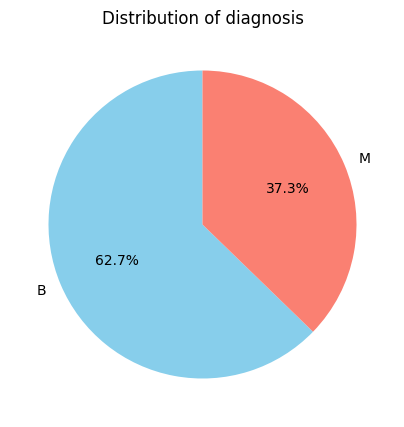

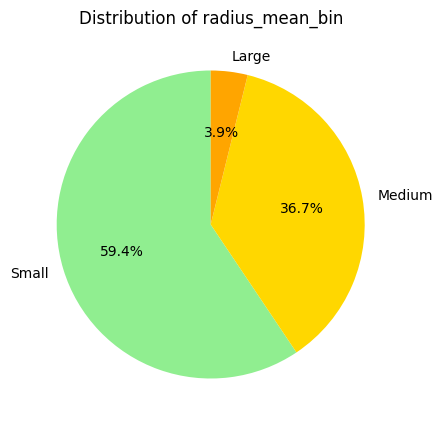

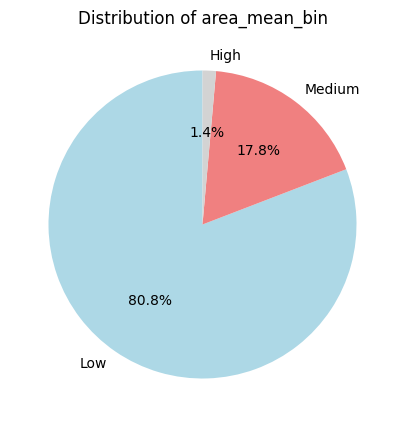

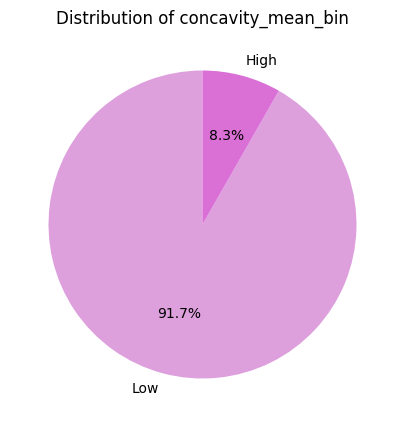

In [19]:
import matplotlib.pyplot as plt

pie_vars = ['diagnosis', 'radius_mean_bin', 'area_mean_bin', 'concavity_mean_bin']

colors_list = [
    ['skyblue', 'salmon'], # diagnosis
    ['lightgreen', 'gold', 'orange'], # radius_mean_bin
    ['lightblue', 'lightcoral', 'lightgrey'], # area_mean_bin
    ['plum', 'orchid'] # concavity_mean_bin
]

for i, col in enumerate(pie_vars):
    counts = data[col].value_counts()
    plt.figure(figsize = (5, 5))
    plt.pie(counts, labels = counts.index, autopct = '%1.1f%%', startangle = 90, colors = colors_list[i])
    plt.title(f'Distribution of {col}')
    plt.show()

### Clustered Bar Charts

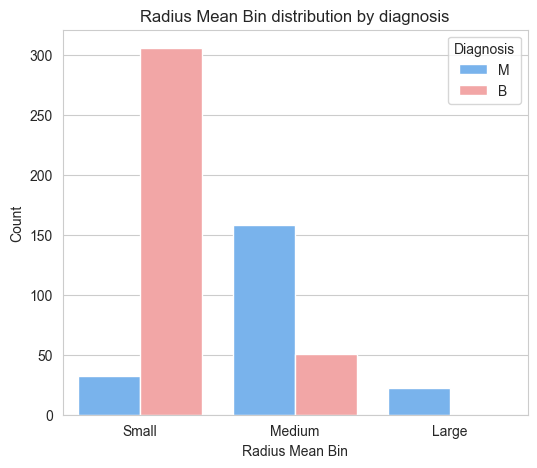

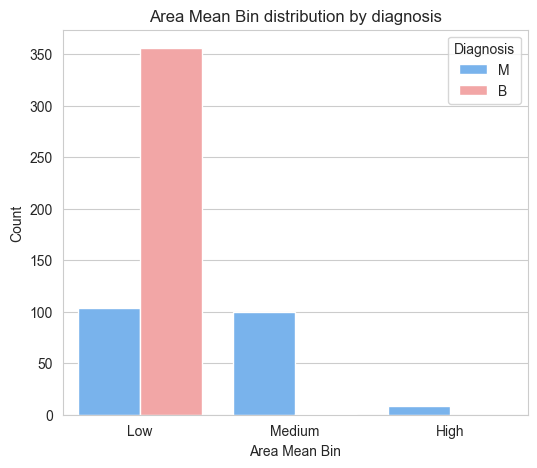

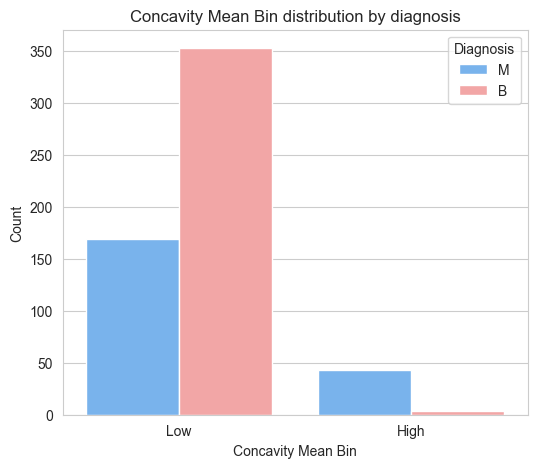

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# set style
sns.set_style('whitegrid')

# lists of categorical columns
condition_vars = ['radius_mean_bin', 'area_mean_bin', 'concavity_mean_bin']
for col in condition_vars:
    plt.figure(figsize = (6, 5))
    sns.countplot(data = data, x = col, hue = 'diagnosis', palette = ['#66b3ff', '#ff9999'])
    plt.title(f'{col.replace('_', ' ').title()} distribution by diagnosis')
    plt.xlabel(col.replace('_', ' ').title())
    plt.ylabel('Count')
    plt.legend(title = 'Diagnosis')
    plt.xticks(rotation = 0) # rotate labels if too long
    plt.show()

### Stacked Histogram

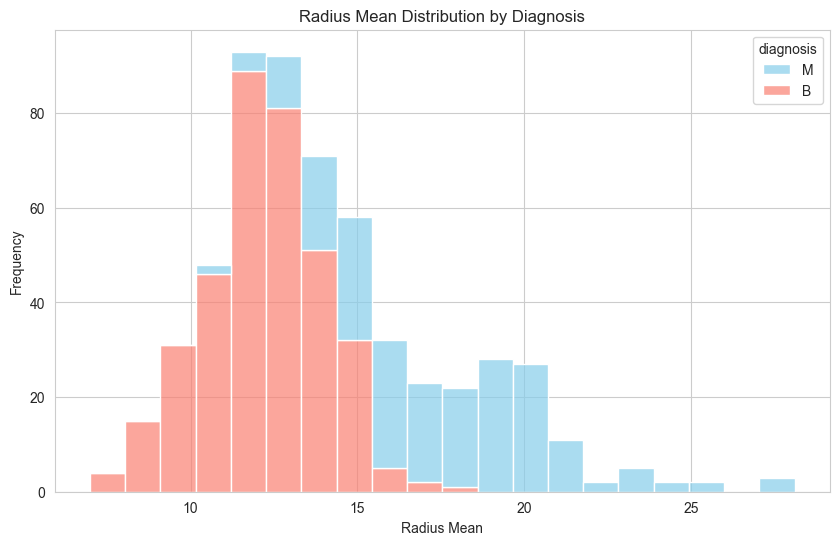

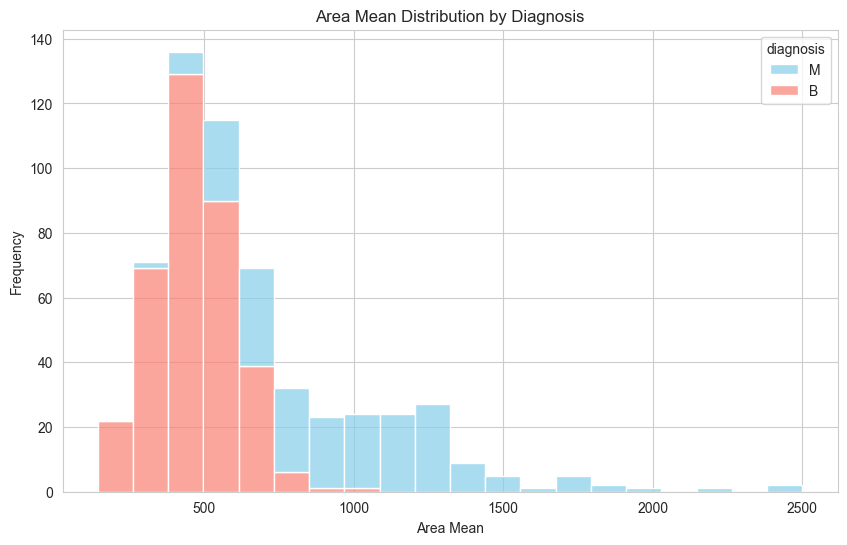

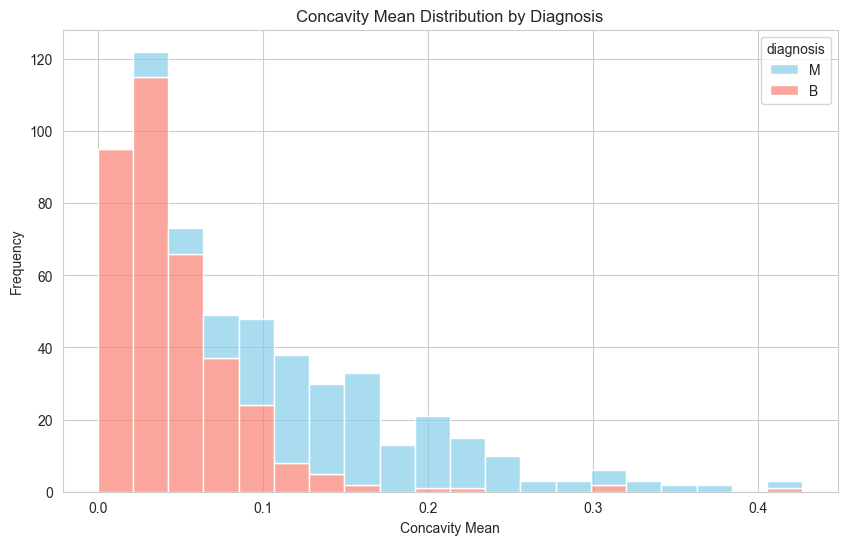

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style('whitegrid')

# Radius Mean
plt.figure(figsize = (10, 6))
sns.histplot(data = data, x = 'radius_mean', bins = 20, hue = 'diagnosis', palette = ['skyblue', 'salmon'], alpha = 0.7, kde = False, 
             multiple = 'stack')
plt.title('Radius Mean Distribution by Diagnosis')
plt.xlabel('Radius Mean')
plt.ylabel('Frequency')
plt.show()

# Area Mean
plt.figure(figsize = (10, 6))
sns.histplot(data = data, x = 'area_mean', bins =20, hue = 'diagnosis', palette = ['skyblue', 'salmon'], alpha = 0.7, kde = False,
            multiple = 'stack')
plt.title('Area Mean Distribution by Diagnosis')
plt.xlabel('Area Mean')
plt.ylabel('Frequency')
plt.show()

# Concavity Mean
plt.figure(figsize = (10, 6))
sns.histplot(data = data, x = 'concavity_mean', bins = 20, hue = 'diagnosis', palette = ['skyblue', 'salmon'], alpha = 0.7, kde = False,
            multiple = 'stack')
plt.title('Concavity Mean Distribution by Diagnosis')
plt.xlabel('Concavity Mean')
plt.ylabel('Frequency')
plt.show()

### Scatter Plot

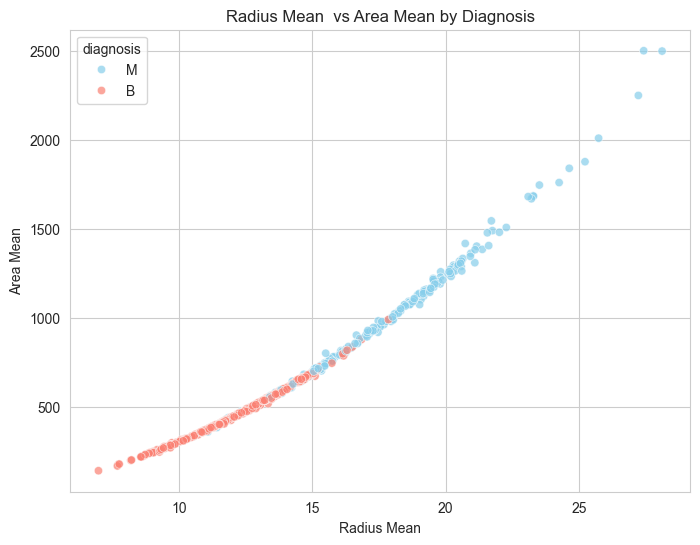

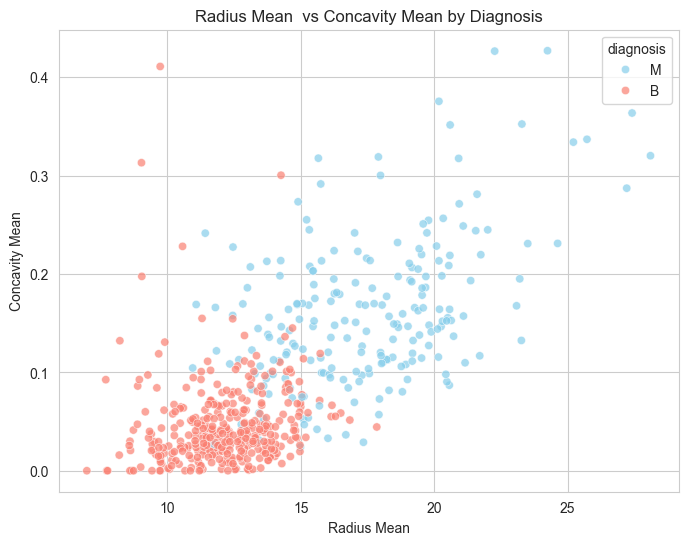

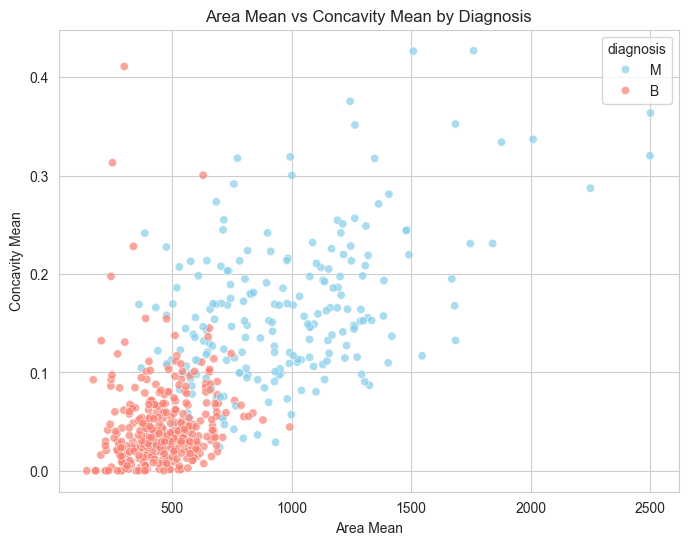

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# Radius Mean vs Area Mean
plt.figure(figsize = (8, 6))
sns.scatterplot(data = data, x = 'radius_mean', y = 'area_mean', hue = 'diagnosis', palette = ['skyblue', 'salmon'], alpha = 0.7)
plt.title('Radius Mean  vs Area Mean by Diagnosis')
plt.xlabel('Radius Mean')
plt.ylabel('Area Mean')
plt.show()

# Radius Mean vs Concavity Mean
plt.figure(figsize = (8, 6))
sns.scatterplot(data = data, x = 'radius_mean', y = 'concavity_mean', hue = 'diagnosis', palette = ['skyblue', 'salmon'], alpha = 0.7)
plt.title('Radius Mean  vs Concavity Mean by Diagnosis')
plt.xlabel('Radius Mean')
plt.ylabel('Concavity Mean')
plt.show()

# Area Mean vs Concavity Mean
plt.figure(figsize = (8, 6))
sns.scatterplot(data = data, x = 'area_mean', y = 'concavity_mean', hue = 'diagnosis', palette = ['skyblue', 'salmon'], alpha = 0.7)
plt.title('Area Mean vs Concavity Mean by Diagnosis')
plt.xlabel('Area Mean')
plt.ylabel('Concavity Mean')
plt.show()

### Box Plot

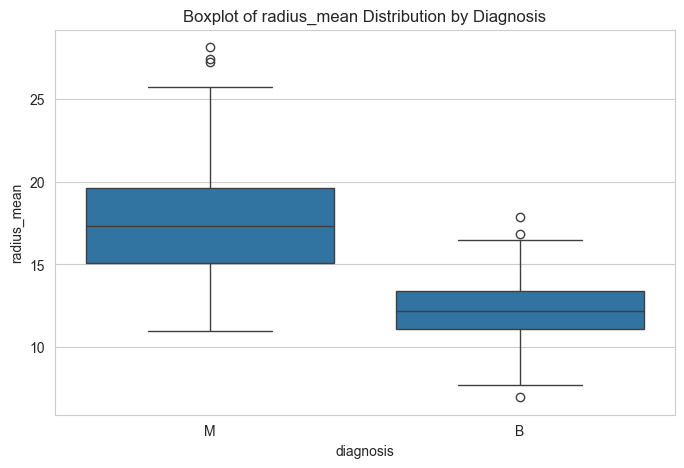

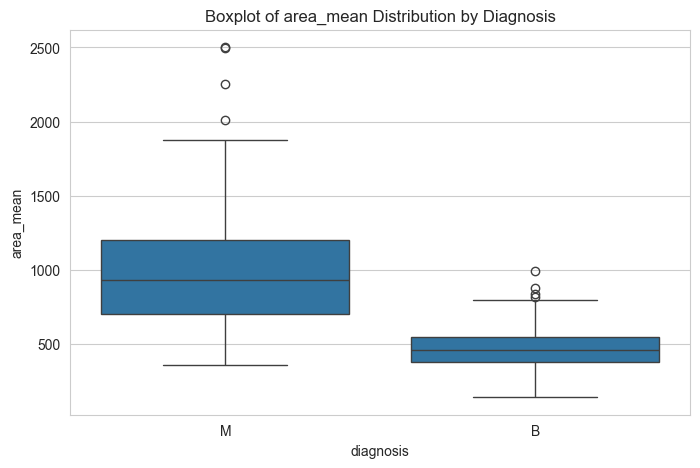

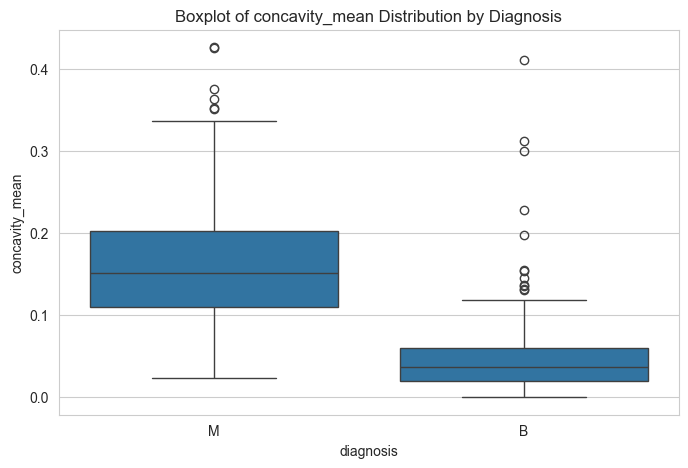

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style('whitegrid')

numeric_vars = ['radius_mean', 'area_mean', 'concavity_mean']
for col in numeric_vars:
    plt.figure(figsize = (8, 5))
    sns.boxplot(data = data, x = 'diagnosis', y = col)
    plt.title(f'Boxplot of {col} Distribution by Diagnosis')
    plt.xlabel('diagnosis')
    plt.ylabel(col)
    plt.show()

### Correlation Heatmap

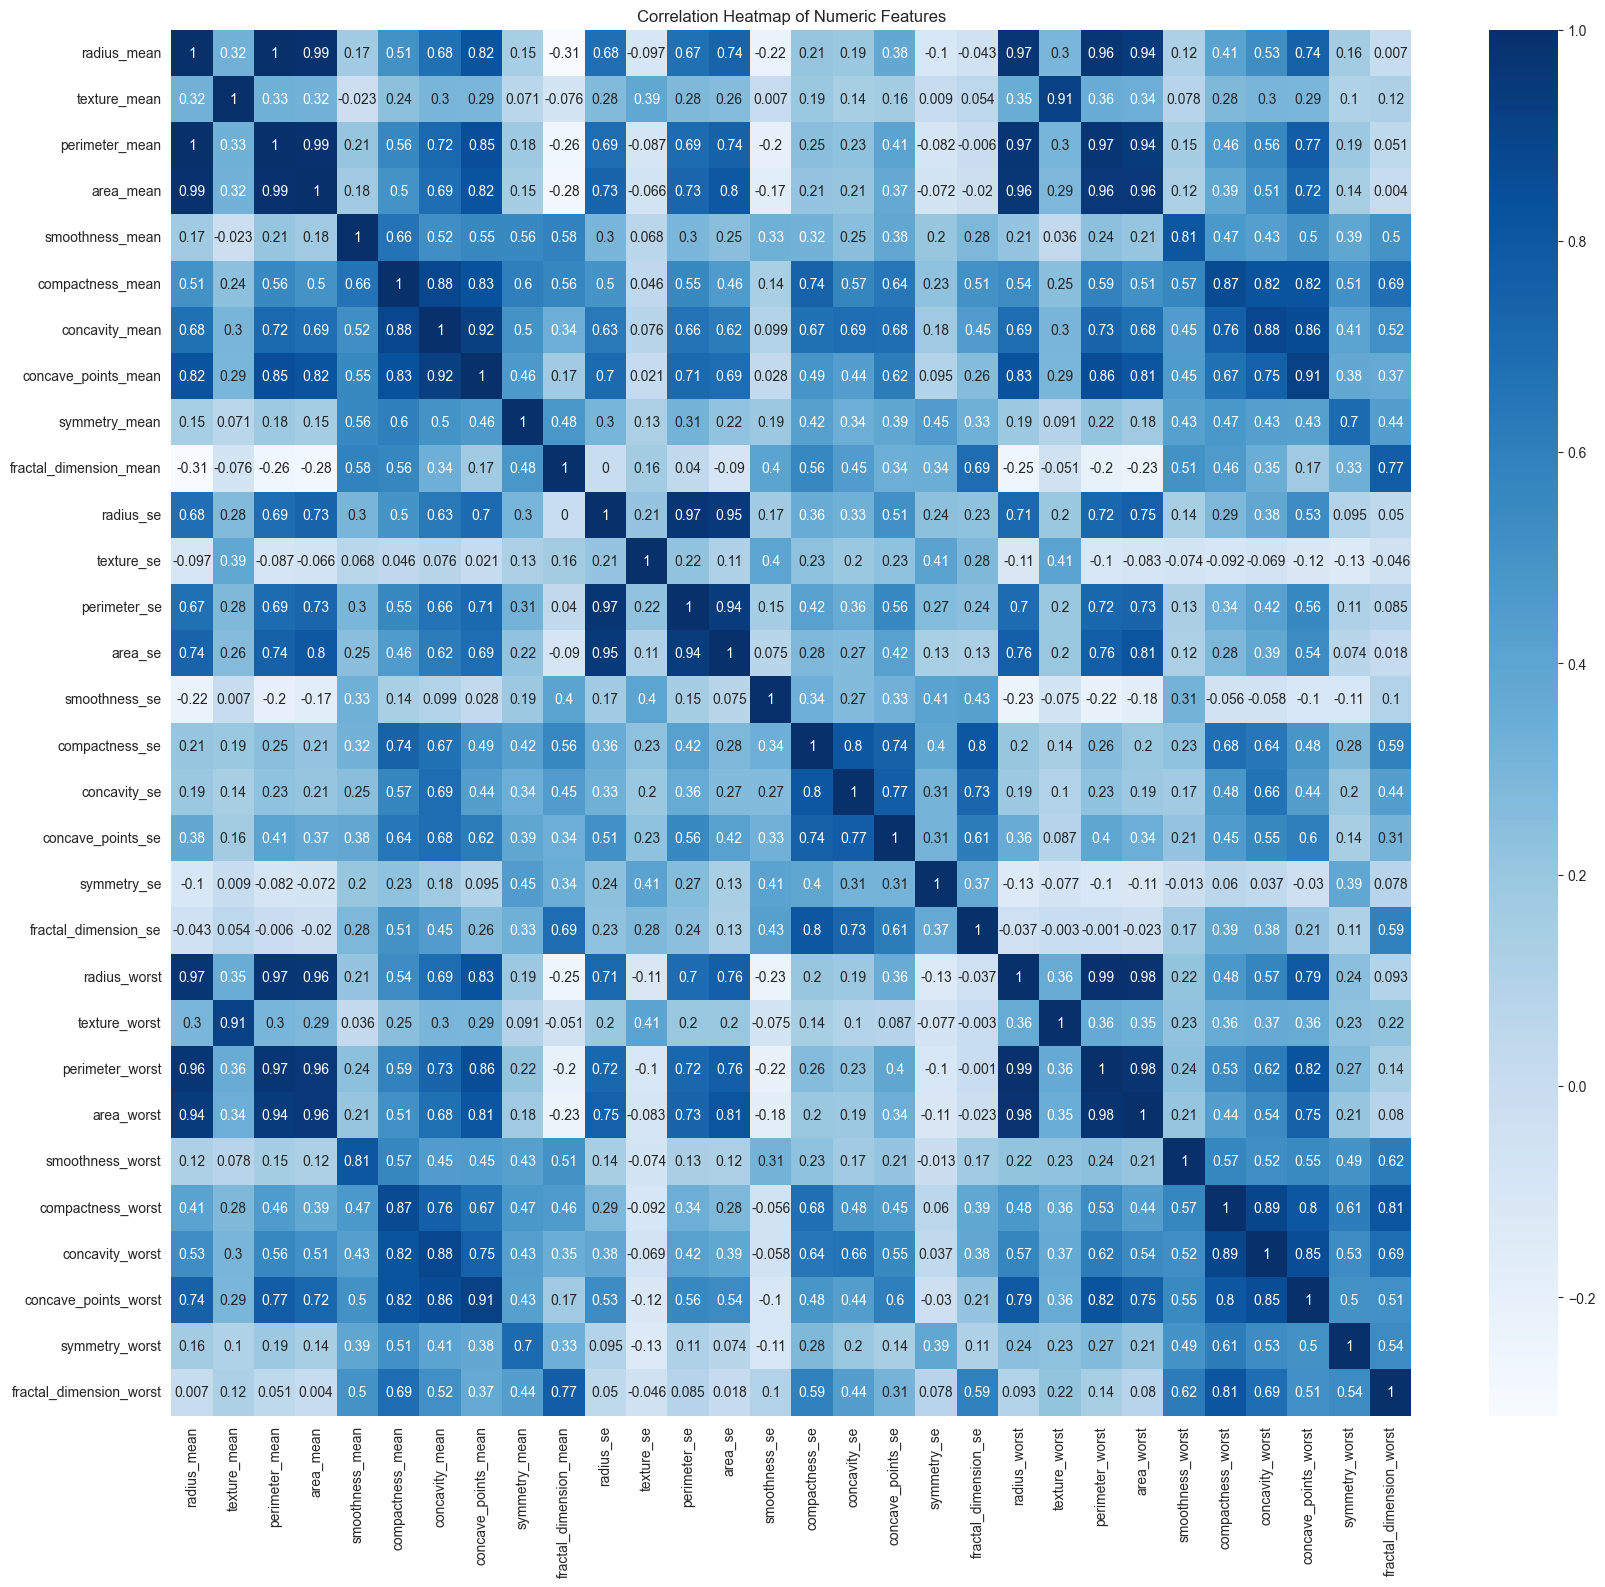

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize = (20, 18))
sns.heatmap(correlation, annot = True, cmap = 'Blues')
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

In [25]:
data.to_csv('C:/Users/user/Desktop/Morufat project/breast_cancer_cleaned.csv', index = False)

In [26]:
data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst,radius_mean_bin,area_mean_bin,concavity_mean_bin,diagnosis_encoded
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,Medium,Medium,High,1
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,Medium,Medium,Low,1
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,Medium,Medium,Low,1
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,Small,Low,High,1
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,Medium,Medium,Low,1
